# Notebook 04: **similitud entre oraciones y clasificación de texto**

**Curso:** Procesamiento de Lenguaje Natural — Especialización en Inteligencia Artificial, Universidad de Cundinamarca
**Docente:** Paul Alexander Díaz Montaña
**Autor:** Yohan Nicolás Gómez Castañeda
**Base:** laboratorio de clase *Course 3 – Week 2* (Moroney, `dlaicourse`): `Tokenizer`, `pad_sequences`, `Embedding` y
`GlobalAveragePooling1D` sobre el corpus de noticias de la BBC.

---

## Objetivo

Medir hasta dónde llega una representación **vectorial sin contexto** en las dos tareas que dependen de ella:
decidir si dos oraciones significan lo mismo (*sentence similarity*) y asignar un tema a una noticia
(*text classification*). Se comparan cinco representaciones construidas sobre el mismo corpus y el mismo
preprocesamiento, de modo que las diferencias se atribuyan a la representación y no a la limpieza del texto.

| Sección | Tema | Pregunta que responde |
|---|---|---|
| 1 | Corpus y conjuntos de evaluación | ¿Sobre qué texto y con qué anotación humana se mide? |
| 2 | Similitud entre oraciones | ¿Qué representación se acerca más al juicio humano y en qué fenómenos lingüísticos falla cada una? |
| 3 | Recuperación de noticias similares | ¿Sirve la similitud para buscar? ¿Qué aporta la reducción de dimensionalidad frente al TF-IDF literal? |
| 4 | Clasificación de temas | ¿Qué modelo clasifica mejor, cuánto texto anotado necesita y qué confunde? |
| 5 | Exportación de métricas | — |
| 6 | Hallazgos | — |

## 0. Configuración del entorno

In [1]:
# Funciona igual en Google Colab y en local. En Colab clona el repositorio para disponer del paquete `pln_lab`,
# descarga el modelo de spaCy e instala TensorFlow si hace falta.
import importlib.util, os, subprocess, sys
from pathlib import Path

# NLTK debe autorizarse antes de cualquier descarga cuando la salida pasa por un proxy.
os.environ.setdefault("NLTK_ALLOW_PROXIED_URLOPEN", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")   # silencia los avisos de compilación de TensorFlow

REPO = "https://github.com/Nicolas2322/lab-procesamiento-texto.git"
EN_COLAB = "google.colab" in sys.modules

def raiz_del_repositorio() -> Path:
    for candidata in [Path.cwd(), *Path.cwd().parents]:
        if (candidata / "src" / "pln_lab").exists():
            return candidata
    if EN_COLAB:
        destino = Path("/content/lab-procesamiento-texto")
        if not destino.exists():
            subprocess.run(["git", "clone", "-q", REPO, str(destino)], check=True)
        return destino
    raise FileNotFoundError("Ejecute el notebook desde la carpeta del repositorio.")

RAIZ = raiz_del_repositorio()
sys.path.insert(0, str(RAIZ / "src"))

if importlib.util.find_spec("es_core_news_md") is None:
    subprocess.run([sys.executable, "-m", "spacy", "download", "es_core_news_md", "-q"], check=True)
if importlib.util.find_spec("tensorflow") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tensorflow-cpu"], check=True)

print("Raíz del repositorio:", RAIZ, "| Colab:", EN_COLAB)

Raíz del repositorio: /home/claude/lab-procesamiento-texto | Colab: False


In [2]:
import json, random, time, warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gensim, sklearn, spacy
from gensim.models import Word2Vec
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_predict
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.svm import LinearSVC

from pln_lab.corpus import cargar_documentos_efe, documentos_a_dataframe
from pln_lab.generacion import TokenizadorPalabras
from pln_lab.preprocesamiento import (
    NEGACIONES, cargar_spacy, es_palabra, quitar_cabecera_agencia, stopwords_nltk,
)
from pln_lab.similitud import (
    coseno_pares, escalar_minmax, pesos_sif, precision_en_k, promedio_ponderado,
    promedio_vectores, quitar_componente_principal,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DIR_FIG = RAIZ / "notebooks" / "figuras"; DIR_RES = RAIZ / "notebooks" / "resultados"
for d in (DIR_FIG, DIR_RES):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
AZUL, ROJO, VERDE, GRIS, NARANJA, MORADO = "#2563eb", "#dc2626", "#16a34a", "#6b7280", "#d97706", "#7c3aed"
pd.set_option("display.max_colwidth", 90)

METRICAS = {}

def guardar_figura(nombre):
    plt.savefig(DIR_FIG / f"{nombre}.png"); plt.show()

def pct(x, d=1):
    return f"{100 * x:.{d}f} %"

print("scikit-learn", sklearn.__version__, "| gensim", gensim.__version__, "| spaCy", spacy.__version__)

scikit-learn 1.8.0 | gensim 4.4.0 | spaCy 3.8.16


## 1. Corpus, representación léxica base y conjuntos de evaluación

Todas las representaciones se construyen sobre el mismo texto y el mismo preprocesamiento, el que el notebook 01
dejó recomendado: se elimina la cabecera de agencia, se lematiza con spaCy (`es_core_news_md`) y se quitan las
stopwords de NLTK **sin las negaciones** (`stopwords_nltk() - NEGACIONES`). Mantener las negaciones es deliberado:
el conjunto de similitud incluye pares que solo se distinguen por un *no*, y con la lista estándar esas oraciones
quedarían idénticas antes de vectorizar.

Se usan dos conjuntos de evaluación anotados a mano:

- `datos/sts_es.csv`: 26 pares de oraciones con una puntuación de similitud de 0 a 5 al estilo de las tareas
  *Semantic Textual Similarity* de SemEval. Cada par lleva además la etiqueta del **fenómeno lingüístico** que pone a
  prueba (paráfrasis, brecha léxica, negación o antónimo, roles invertidos, detalle cambiado, mismo tema, polisemia,
  sin relación). Esa columna es la que permite pasar de «este método correlaciona 0,5» a «este método falla
  exactamente aquí».
- `datos/temas_efe.csv`: 70 noticias del corpus etiquetadas con uno de cinco temas, 14 por tema.

In [3]:
documentos = cargar_documentos_efe()
corpus = documentos_a_dataframe(documentos)
nlp = cargar_spacy()                      # tagger + morphologizer + lemmatizer, sin parser ni NER
STOPWORDS = stopwords_nltk() - NEGACIONES

def lemas_de_contenido(doc_spacy):
    """Lemas en minúscula de las palabras que no son stopwords ni signos ni marcadores."""
    return [t.lemma_.lower() for t in doc_spacy
            if es_palabra(t.text) and t.text.lower() not in STOPWORDS]

t0 = time.time()
textos_limpios = [quitar_cabecera_agencia(t) for t in corpus.texto]
lemas_corpus = [lemas_de_contenido(d) for d in nlp.pipe(textos_limpios, batch_size=32)]
corpus_lem = [" ".join(l) for l in lemas_corpus]
print(f"Corpus lematizado en {time.time() - t0:.1f} s")

resumen = pd.Series({
    "Noticias": len(corpus),
    "Tokens (CoNLL)": int(corpus.n_tokens.sum()),
    "Lemas de contenido": sum(len(l) for l in lemas_corpus),
    "Lemas distintos": len({l for doc in lemas_corpus for l in doc}),
}, name="valor")
METRICAS["corpus"] = {k: int(v) for k, v in resumen.items()}
display(resumen.to_frame())
print(corpus_lem[1][:220], "…")

Corpus lematizado en 15.4 s


,valor
Noticias,998
Tokens (CoNLL),369171
Lemas de contenido,164491
Lemas distintos,17670


izquierda unida santander presentar hoy nuevo boletín trimestral ciudad publicación distribuir ejemplar preferentemente barrio municipio colación contar mayor respaldo ciudadano portavoz consejo político municipal iu san …


In [4]:
sts = pd.read_csv(RAIZ / "datos" / "sts_es.csv")
temas = pd.read_csv(RAIZ / "datos" / "temas_efe.csv")

# Los pares de similitud se lematizan con el mismo procedimiento que el corpus.
frases = list(sts.frase1) + list(sts.frase2)
lemas_frases = [lemas_de_contenido(d) for d in nlp.pipe(frases, batch_size=32)]
N_PARES = len(sts)
lemas_a, lemas_b = lemas_frases[:N_PARES], lemas_frases[N_PARES:]
texto_a = [" ".join(l) for l in lemas_a]
texto_b = [" ".join(l) for l in lemas_b]
y_humano = sts.similitud.to_numpy()

# Las 70 noticias etiquetadas: su representación léxica sale del corpus ya lematizado.
docs_temas = [corpus_lem[i] for i in temas.id_doc]
tokens_temas = [lemas_corpus[i] for i in temas.id_doc]
y_tema = temas.tema.to_numpy()
CLASES = sorted(set(y_tema))

METRICAS["evaluacion"] = {
    "pares_sts": int(N_PARES), "fenomenos": int(sts.categoria.nunique()),
    "noticias_etiquetadas": int(len(temas)), "temas": len(CLASES),
}
print("Pares de similitud por fenómeno:")
display(sts.groupby("categoria").agg(pares=("similitud", "size"), similitud_media=("similitud", "mean")).round(2))
print("Noticias por tema:", temas.tema.value_counts().to_dict())
display(sts.head(3))

Pares de similitud por fenómeno:


,pares,similitud_media
categoria,,
brecha léxica,5,4.48
detalle cambiado,2,2.80
mismo tema,3,1.20
negación o antónimo,4,1.50
paráfrasis,4,4.40
polisemia,3,0.33
roles invertidos,2,1.50
sin relación,3,0.00


Noticias por tema: {'deportes': 14, 'economía': 14, 'cultura': 14, 'sucesos y justicia': 14, 'política': 14}


,categoria,frase1,frase2,similitud
0,paráfrasis,El Gobierno aprobó la reforma de la ley de educación.,La reforma educativa fue aprobada por el Ejecutivo.,4.6
1,paráfrasis,Las lluvias han causado al menos 28 muertos en Colombia.,Al menos 28 personas murieron por las inundaciones en Colombia.,4.4
2,paráfrasis,El Real Madrid ganó la final de la Liga de Campeones.,El Real Madrid se proclamó campeón de Europa.,4.2


**Análisis.** El corpus aporta el material estadístico (998 noticias, 164.491 lemas de contenido y 17.670 lemas
distintos) con el que se estiman los pesos IDF y se entrenan los modelos de embeddings; los dos conjuntos anotados
aportan la referencia humana. La desproporción es deliberada y refleja la situación habitual: hay mucho texto sin
anotar y muy poco anotado, de modo que toda la información semántica que las representaciones puedan extraer tiene
que venir del texto no anotado.

El conjunto de similitud no es una muestra aleatoria sino un **diseño**: los ocho fenómenos cubren el rango completo
de la escala (de 0,0 en los pares sin relación a 4,5 en las paráfrasis) y están elegidos para separar dos capacidades
que las métricas globales confunden. Los pares de *brecha léxica* premian a quien reconoce sinónimos sin
solapamiento de palabras (*euro/moneda europea*, *médico/doctor*); los de *negación o antónimo*, *roles invertidos* y
*polisemia* castigan a quien solo mira qué palabras aparecen, porque ahí las palabras son casi las mismas y el
significado es distinto. Una correlación global alta obtenida sin resolver el segundo grupo indica un método que
acierta por la razón equivocada.

## 2. Similitud entre oraciones (*sentence similarity*)

La tarea consiste en asignar a un par de oraciones un número que ordene los pares igual que lo haría una persona.
Todos los métodos de esta sección siguen el mismo esquema: cada oración se convierte en **un solo vector** y la
similitud es el **coseno** entre los dos vectores. Cambia únicamente cómo se obtiene ese vector.

### 2.1 Las cinco representaciones

| Método | Vector de la oración | Qué información usa |
|---|---|---|
| TF-IDF | pesos TF-IDF de sus lemas, dimensión = vocabulario | coincidencia literal de lemas, ponderada por rareza |
| LSA | proyección del vector TF-IDF en 150 dimensiones obtenidas con SVD truncado sobre el corpus | coocurrencia de lemas en las 998 noticias |
| spaCy (promedio) | media de los vectores estáticos de `es_core_news_md` (20.000 vectores de 300 dimensiones) | coocurrencia en el corpus de entrenamiento del modelo (mucho mayor) |
| Word2Vec (promedio) | media de los vectores skip-gram entrenados con gensim sobre las 998 noticias | coocurrencia en ventanas de 5 palabras del corpus propio |
| Word2Vec + SIF | media ponderada por a/(a+p(w)) menos su primera componente principal | lo mismo, quitando el peso de lo frecuente y la dirección común |

Las tres últimas usan *vectores estáticos*: cada palabra tiene un único vector, igual en todos los contextos. Es la
limitación que la sección 2.4 examina.

In [5]:
# --- 1. TF-IDF. El vocabulario y los pesos IDF se estiman sobre el corpus completo (998 noticias) más las
# oraciones de evaluación, para que ningún lema del conjunto anotado quede fuera de vocabulario.
vectorizador = TfidfVectorizer(min_df=1, sublinear_tf=True)
vectorizador.fit(corpus_lem + texto_a + texto_b)
X_corpus = vectorizador.transform(corpus_lem)
A_tfidf, B_tfidf = vectorizador.transform(texto_a), vectorizador.transform(texto_b)
print("Vocabulario TF-IDF:", len(vectorizador.vocabulary_), "| matriz del corpus:", X_corpus.shape,
      f"| densidad {X_corpus.nnz / np.prod(X_corpus.shape):.4f}")

# --- 2. LSA: SVD truncado de la matriz TF-IDF del corpus (Deerwester et al., 1990).
N_LSA = 150
lsa = TruncatedSVD(n_components=N_LSA, random_state=SEED).fit(X_corpus)
A_lsa, B_lsa = lsa.transform(A_tfidf), lsa.transform(B_tfidf)
print(f"LSA: {N_LSA} componentes, varianza explicada {pct(lsa.explained_variance_ratio_.sum())}")

Vocabulario TF-IDF: 17234 | matriz del corpus: (998, 17234) | densidad 0.0070


LSA: 150 componentes, varianza explicada 34.5 %


In [6]:
# --- 3. Vectores estáticos de spaCy: se consultan por lema y se promedian.
DIM_SPACY = nlp.vocab.vectors.shape[1]

def vector_spacy(palabra):
    lexema = nlp.vocab[palabra]
    return lexema.vector if lexema.has_vector and lexema.vector_norm > 0 else None

cobertura_spacy = np.mean([vector_spacy(t) is not None for l in lemas_frases for t in l])
A_spacy = np.vstack([promedio_vectores(l, vector_spacy, DIM_SPACY) for l in lemas_a])
B_spacy = np.vstack([promedio_vectores(l, vector_spacy, DIM_SPACY) for l in lemas_b])
print(f"spaCy: {nlp.vocab.vectors.shape[0]} vectores de {DIM_SPACY} dim "
      f"| cobertura de los lemas del conjunto STS {pct(cobertura_spacy)}")

# --- 4. Word2Vec entrenado sobre las 998 noticias lematizadas (skip-gram, Mikolov et al., 2013).
t0 = time.time()
# workers=1 es deliberado: con varios hilos el entrenamiento de gensim es asíncrono y los
# vectores cambian de una ejecución a otra aunque se fije la semilla.
w2v = Word2Vec(sentences=lemas_corpus, vector_size=200, window=5, min_count=3,
               sg=1, epochs=15, workers=1, seed=SEED, sorted_vocab=1)
DIM_W2V = w2v.wv.vector_size

def vector_w2v(palabra):
    return w2v.wv[palabra] if palabra in w2v.wv else None

cobertura_w2v = np.mean([vector_w2v(t) is not None for l in lemas_frases for t in l])
A_w2v = np.vstack([promedio_vectores(l, vector_w2v, DIM_W2V) for l in lemas_a])
B_w2v = np.vstack([promedio_vectores(l, vector_w2v, DIM_W2V) for l in lemas_b])
print(f"Word2Vec: {len(w2v.wv)} palabras, {DIM_W2V} dim, entrenado en {time.time() - t0:.1f} s "
      f"| cobertura STS {pct(cobertura_w2v)}")

# --- 5. SIF sobre los mismos vectores Word2Vec (Arora et al., 2017): promedio ponderado por a/(a+p(w))
# y eliminación de la primera componente principal del conjunto de oraciones.
A_SIF = 1e-3
pesos = pesos_sif(lemas_corpus, a=A_SIF)
sif = np.vstack([promedio_ponderado(l, vector_w2v, pesos, DIM_W2V) for l in lemas_frases])
sif = quitar_componente_principal(sif, n_componentes=1)
A_sif, B_sif = sif[:N_PARES], sif[N_PARES:]
print("SIF: pesos estimados sobre", len(pesos), "lemas; primera componente principal eliminada")

spaCy: 20000 vectores de 300 dim | cobertura de los lemas del conjunto STS 99.2 %


Word2Vec: 7537 palabras, 200 dim, entrenado en 14.7 s | cobertura STS 97.2 %
SIF: pesos estimados sobre 17670 lemas; primera componente principal eliminada


In [7]:
# Coseno por pares con cada representación.
def coseno_disperso(A, B):
    return np.array([cosine_similarity(A[i], B[i])[0, 0] for i in range(A.shape[0])])

similitudes = pd.DataFrame({
    "TF-IDF": coseno_disperso(A_tfidf, B_tfidf),
    "LSA": coseno_pares(A_lsa, B_lsa),
    "spaCy prom.": coseno_pares(A_spacy, B_spacy),
    "Word2Vec prom.": coseno_pares(A_w2v, B_w2v),
    "Word2Vec + SIF": coseno_pares(A_sif, B_sif),
})
METODOS = list(similitudes.columns)
similitudes.insert(0, "categoria", sts.categoria.values)
similitudes.insert(1, "humano", y_humano)
display(similitudes.round(3).head(8))

,categoria,humano,TF-IDF,LSA,spaCy prom.,Word2Vec prom.,Word2Vec + SIF
0,paráfrasis,4.6,0.473,0.772,0.853,0.869,0.837
1,paráfrasis,4.4,0.319,0.732,0.765,0.898,0.860
2,paráfrasis,4.2,0.230,0.756,0.724,0.917,0.800
3,paráfrasis,4.4,0.687,0.688,0.840,0.898,0.753
4,brecha léxica,4.6,0.016,0.546,0.769,0.850,0.683
5,brecha léxica,4.4,0.000,0.409,0.734,0.749,0.510
6,brecha léxica,4.2,0.055,0.478,0.842,0.869,0.635
7,brecha léxica,4.6,0.157,0.840,0.914,0.944,0.898


### 2.2 Correlación con la anotación humana

La métrica estándar de la tarea es la **correlación de Spearman** entre el orden que produce el método y el que
produce la anotación humana: interesa que los pares queden bien ordenados, no que el coseno coincida numéricamente
con una escala de 0 a 5. Se añade la **correlación de Pearson**, que sí exige una relación lineal, porque la
diferencia entre ambas revela si el método ordena bien pero comprime el rango.

,Spearman,p (Spearman),Pearson,coseno medio,coseno mín.,coseno máx.
método,,,,,,
TF-IDF,0.207,0.309,-0.009,0.349,0.000,1.0
LSA,0.358,0.073,0.325,0.593,-0.000,1.0
spaCy prom.,0.549,0.004,0.507,0.701,0.008,1.0
Word2Vec prom.,0.446,0.022,0.490,0.789,0.179,1.0
Word2Vec + SIF,0.473,0.015,0.518,0.589,-0.443,1.0


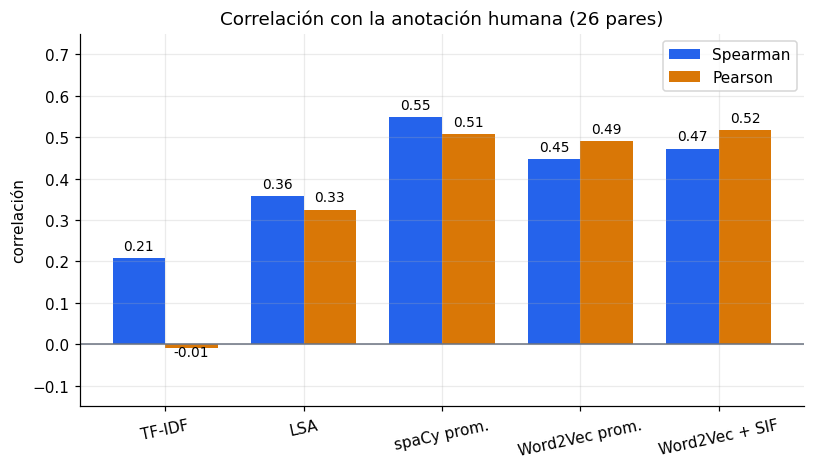

In [8]:
filas = []
for metodo in METODOS:
    s = similitudes[metodo].to_numpy()
    rho, p_rho = spearmanr(s, y_humano)
    r, p_r = pearsonr(s, y_humano)
    filas.append({"método": metodo, "Spearman": rho, "p (Spearman)": p_rho, "Pearson": r,
                  "coseno medio": s.mean(), "coseno mín.": s.min(), "coseno máx.": s.max()})
correlaciones = pd.DataFrame(filas).set_index("método")
METRICAS["sts_correlaciones"] = correlaciones.round(4).to_dict("index")
display(correlaciones.round(3))

x = np.arange(len(METODOS)); ancho = 0.38
fig, eje = plt.subplots(figsize=(8.5, 4.4))
eje.bar(x - ancho / 2, correlaciones.Spearman, ancho, color=AZUL, label="Spearman")
eje.bar(x + ancho / 2, correlaciones.Pearson, ancho, color=NARANJA, label="Pearson")
for i, (rho, r) in enumerate(zip(correlaciones.Spearman, correlaciones.Pearson)):
    eje.text(i - ancho / 2, rho + 0.02 * np.sign(rho or 1), f"{rho:.2f}", ha="center", fontsize=9)
    eje.text(i + ancho / 2, r + 0.02 * np.sign(r or 1), f"{r:.2f}", ha="center", fontsize=9)
eje.axhline(0, color=GRIS, lw=1)
eje.set(title="Correlación con la anotación humana (26 pares)", ylabel="correlación", ylim=(-0.15, 0.75))
eje.set_xticks(x); eje.set_xticklabels(METODOS, rotation=12)
eje.legend()
guardar_figura("fig04_01_correlacion_sts")

**Análisis.** El orden de los cinco métodos es nítido y, en parte, contraintuitivo:

| Método | Spearman | p | Pearson | coseno medio |
|---|---|---|---|---|
| TF-IDF | 0,207 | 0,309 | −0,009 | 0,349 |
| LSA (150) | 0,358 | 0,073 | 0,325 | 0,593 |
| spaCy (promedio) | **0,549** | 0,004 | 0,507 | 0,701 |
| Word2Vec (promedio) | 0,446 | 0,022 | 0,490 | 0,789 |
| Word2Vec + SIF | 0,473 | 0,015 | 0,517 | 0,589 |

El **TF-IDF no correlaciona**: ρ = 0,21 con p = 0,31, es decir, indistinguible del azar, y una correlación de Pearson
de −0,01, literalmente nula. No es que ordene mal por ruido: ordena mal de forma sistemática, y la sección 2.3
muestra dónde. Es un resultado importante porque el coseno sobre TF-IDF es la medida de similitud que se usa por
defecto en recuperación de información, y la sección 3 confirma que ahí sí funciona; lo que no funciona es usarla
como aproximación al **significado** de una oración corta.

La **reducción de dimensionalidad ya aporta**: los mismos vectores TF-IDF proyectados en 150 componentes latentes
(que explican el 34,5 % de la varianza) suben la correlación a 0,36, porque el SVD hace que dos oraciones se
parezcan si sus palabras aparecen en las mismas noticias, aunque no compartan ninguna. Pero con 998 noticias la
evidencia de coocurrencia es escasa, y el salto real llega con los **vectores de spaCy** (ρ = 0,55): están entrenados
sobre un corpus mucho mayor que el disponible aquí, y con una cobertura del 99,2 % de los lemas del conjunto de
evaluación. Los vectores Word2Vec entrenados sobre las 998 noticias se quedan en 0,45 con una cobertura del 97,2 %:
la diferencia entre ambos no es de algoritmo, sino de **cantidad de texto no anotado**.

La ponderación **SIF** mejora el promedio simple de Word2Vec en 2,7 puntos de Spearman (0,446 → 0,473) y en otros
2,7 de Pearson (0,490 → 0,517), exactamente el efecto que predicen Arora et al. (2017): bajar el peso de los lemas
frecuentes y quitar la dirección común deja el coseno medio en 0,59 —frente a 0,79 del promedio simple— y permite
valores negativos (mínimo −0,44), mientras que el promedio simple nunca baja de 0,18. El promedio simple **comprime
todo el rango en la mitad superior del coseno**, y eso explica que su Pearson (0,490) supere a su Spearman (0,446):
ordena peor de lo que escala.

Las cinco correlaciones quedan muy lejos de lo que reportan los codificadores contextuales entrenados
específicamente para la tarea (Reimers y Gurevych, 2019, con ρ entre 0,74 y 0,85 en los conjuntos STS). La brecha no
se cierra ajustando hiperparámetros: es la que separa «una oración es la suma de sus palabras» de «una oración es sus
palabras en un orden y un contexto». Con 26 pares, además, solo tres métodos alcanzan significación al 5 %
(spaCy, p = 0,004; SIF, p = 0,015; Word2Vec, p = 0,022), de modo que las diferencias entre esos tres deben leerse
como una tendencia, no como un ranking firme.

### 2.3 Perfil por fenómeno lingüístico

Los cosenos de métodos distintos no son comparables en bruto: el TF-IDF disperso llega a 0 cuando no hay ningún lema
compartido, mientras que los promedios de embeddings casi nunca bajan de 0,3 porque todos los vectores de un mismo
idioma comparten dirección. Para comparar **perfiles** —no valores— cada método se reescala a [0, 1] con
mínimo-máximo sobre los 26 pares y se promedia por fenómeno. La anotación humana se reescala igual.

,humano,TF-IDF,LSA,spaCy prom.,Word2Vec prom.,Word2Vec + SIF
categoria,,,,,,
brecha léxica,0.97,0.05,0.53,0.77,0.79,0.77
paráfrasis,0.96,0.43,0.74,0.79,0.87,0.87
detalle cambiado,0.61,0.74,0.81,0.95,0.92,0.89
negación o antónimo,0.33,0.75,0.92,0.86,0.92,0.93
roles invertidos,0.33,1.00,1.00,1.00,1.00,1.00
mismo tema,0.26,0.04,0.32,0.59,0.63,0.64
polisemia,0.07,0.18,0.49,0.55,0.63,0.51
sin relación,0.00,0.00,0.02,0.13,0.19,0.11


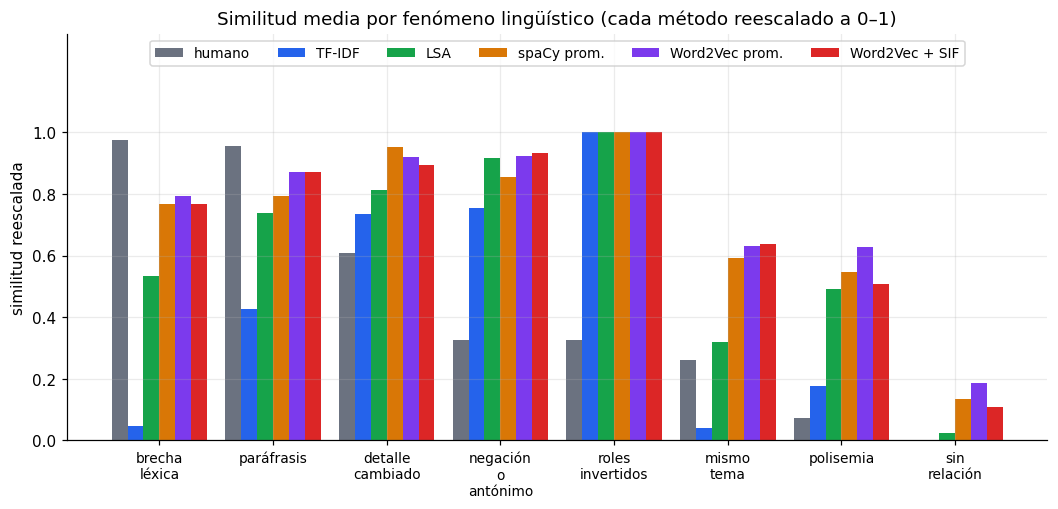

In [9]:
escalado = pd.DataFrame({m: escalar_minmax(similitudes[m]) for m in METODOS})
escalado["humano"] = escalar_minmax(y_humano)
escalado["categoria"] = sts.categoria.values
orden = (sts.groupby("categoria").similitud.mean().sort_values(ascending=False).index.tolist())
perfil = escalado.groupby("categoria")[["humano"] + METODOS].mean().loc[orden]
METRICAS["sts_perfil_fenomeno"] = perfil.round(3).to_dict("index")
display(perfil.round(2))

columnas = ["humano"] + METODOS
colores = [GRIS, AZUL, VERDE, NARANJA, MORADO, ROJO]
x = np.arange(len(perfil)); ancho = 0.14
fig, eje = plt.subplots(figsize=(11.5, 4.8))
for i, col in enumerate(columnas):
    eje.bar(x + (i - len(columnas) / 2 + 0.5) * ancho, perfil[col], ancho, label=col, color=colores[i])
eje.set(title="Similitud media por fenómeno lingüístico (cada método reescalado a 0–1)",
        ylabel="similitud reescalada", ylim=(0, 1.32))
eje.set_xticks(x); eje.set_xticklabels([c.replace(" o ", "\no ").replace(" ", "\n", 1) for c in perfil.index], fontsize=9)
eje.set_yticks(np.arange(0, 1.01, 0.2))
eje.legend(ncol=6, fontsize=9, loc="upper center")
guardar_figura("fig04_02_perfil_fenomenos")

**Análisis.** El perfil humano desciende de forma monótona: brecha léxica 0,97, paráfrasis 0,96, detalle cambiado
0,61, negación y roles invertidos 0,33, mismo tema 0,26, polisemia 0,07 y sin relación 0,00. Ningún método reproduce
esa forma, y cada uno se desvía de una manera distinta.

**Donde gana cada uno.** La *brecha léxica* separa a los métodos con claridad: el TF-IDF cae a 0,04 (frente a 0,97
humano) porque *«el euro bajó frente al dólar»* y *«la moneda europea se depreció respecto a la divisa
estadounidense»* no comparten **ningún lema de contenido**; el coseno es 0,016 en ese par y 0,000 en el de
*médico/doctor*. El LSA lo sube a 0,53 y los embeddings a 0,77–0,79. Esa es la aportación real de los vectores
distribuidos, y explica casi toda su ventaja en la correlación global. En *paráfrasis*, donde hay solapamiento
parcial, la distancia es menor (0,43 del TF-IDF frente a 0,87 de Word2Vec).

**Donde fallan todos.** Los tres fenómenos que la sección 1 anticipaba se comportan como se esperaba y en el mismo
orden para los cinco métodos:

- *Roles invertidos*: **1,00 en los cinco métodos**, el valor máximo posible, frente a 0,33 humano. *«El Real Madrid
  venció al Valencia»* y *«El Valencia venció al Real Madrid»* tienen exactamente el mismo conjunto de lemas, de modo
  que TF-IDF, LSA, promedio de vectores y SIF producen vectores **idénticos** y un coseno de 1,0 exacto. No es un
  error de estimación: es una imposibilidad de la representación, porque ni la bolsa de palabras ni la media de
  vectores conservan el orden.
- *Negación o antónimo*: 0,76 (TF-IDF) a 0,93 (SIF) frente a 0,33 humano. El preprocesamiento **conserva las
  negaciones** —sin eso el coseno sería 1,0 también aquí—, pero conservarlas apenas ayuda: el *no* añade un lema
  entre cuatro o cinco, y en la media de vectores su contribución se diluye. Con los antónimos el problema es más
  profundo: *aumentar* y *disminuir* aparecen en los mismos contextos («las reservas ⟨verbo⟩ en mayo»), así que la
  hipótesis distribucional los coloca **cerca**, no lejos. Los embeddings no solo no resuelven la antonimia: la
  agravan respecto al TF-IDF.
- *Polisemia*: de 0,18 (TF-IDF) a 0,63 (Word2Vec promedio) frente a 0,07 humano. *«El banco del parque»* y *«el banco
  subió las comisiones»* comparten la forma *banco*, y un vector estático tiene **un solo vector por forma**, que
  mezcla los dos sentidos. Aquí el TF-IDF es paradójicamente el menos malo, porque al menos no propaga la confusión a
  los lemas vecinos; los embeddings sí, y por eso su valor es el triple.

**El costo de los embeddings.** El reverso aparece en *mismo tema* y *sin relación*. El TF-IDF acierta casi
perfectamente ahí (0,04 y 0,00 frente a 0,26 y 0,00 humano): si no hay palabras compartidas, no hay similitud. Los
embeddings inflan *mismo tema* hasta 0,59–0,64 y *sin relación* hasta 0,11–0,19, porque miden **cercanía temática**,
no equivalencia semántica: *«el Real Madrid ganó la Liga de Campeones»* y *«el Valencia fichó a un entrenador»* viven
en la misma región del espacio. Para recuperación de información eso es una virtud (sección 3); para decidir si dos
oraciones dicen lo mismo, es un falso positivo.

### 2.4 Los pares que ningún método resuelve

Para cuantificar el fallo se calcula, por par, el **error de orden**: la diferencia entre la similitud reescalada del
método y la del anotador humano. Un valor positivo grande significa que el método considera las dos oraciones mucho
más parecidas de lo que son.

,TF-IDF,LSA,spaCy prom.,Word2Vec prom.,Word2Vec + SIF,promedio
categoria,,,,,,
roles invertidos,0.67,0.67,0.67,0.67,0.67,0.67
negación o antónimo,0.43,0.59,0.53,0.60,0.61,0.55
polisemia,0.10,0.42,0.47,0.56,0.44,0.40
detalle cambiado,0.13,0.20,0.34,0.31,0.28,0.25
mismo tema,-0.22,0.06,0.33,0.37,0.38,0.18
sin relación,0.00,0.02,0.13,0.19,0.11,0.09
paráfrasis,-0.53,-0.22,-0.16,-0.08,-0.09,-0.22
brecha léxica,-0.93,-0.44,-0.21,-0.18,-0.21,-0.39


Pares que todos los métodos sobrevaloran (error medio de orden):


,categoria,frase1,frase2,humano,promedio
13,roles invertidos,El Real Madrid venció al Valencia.,El Valencia venció al Real Madrid.,1.5,0.67
14,roles invertidos,El banco compró la empresa de telefonía.,La empresa de telefonía compró el banco.,1.5,0.67
12,negación o antónimo,Las reservas internacionales de Chile aumentaron en mayo.,Las reservas internacionales de Chile disminuyeron en mayo.,1.5,0.60
9,negación o antónimo,El acuerdo fue aprobado por el Congreso.,El acuerdo no fue aprobado por el Congreso.,1.5,0.59
11,negación o antónimo,La empresa aumentó sus beneficios este año.,La empresa redujo sus beneficios este año.,1.5,0.54


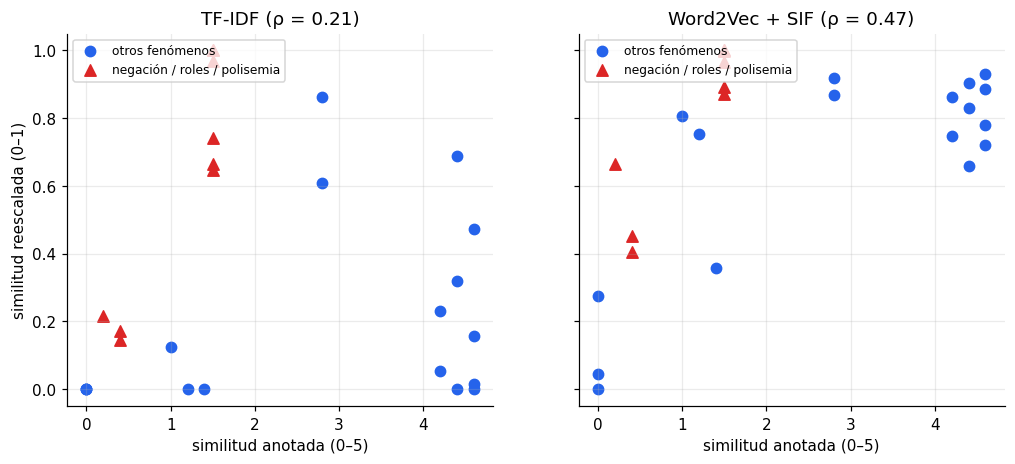

In [10]:
errores = pd.DataFrame({m: escalado[m] - escalado["humano"] for m in METODOS})
errores["categoria"] = sts.categoria.values
error_medio = errores.groupby("categoria")[METODOS].mean().assign(promedio=lambda d: d.mean(axis=1))
error_medio = error_medio.sort_values("promedio", ascending=False)
METRICAS["sts_error_por_fenomeno"] = error_medio.round(3).to_dict("index")
display(error_medio.round(2))

peores = (errores.assign(promedio=errores[METODOS].mean(axis=1),
                         frase1=sts.frase1.values, frase2=sts.frase2.values, humano=y_humano)
          .sort_values("promedio", ascending=False).head(5))
print("Pares que todos los métodos sobrevaloran (error medio de orden):")
display(peores[["categoria", "frase1", "frase2", "humano", "promedio"]].round(2))

fig, ejes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
grupos_criticos = ["negación o antónimo", "roles invertidos", "polisemia"]
for eje, metodo in zip(ejes, ["TF-IDF", "Word2Vec + SIF"]):
    critico = sts.categoria.isin(grupos_criticos).values
    eje.scatter(y_humano[~critico], escalado[metodo][~critico], color=AZUL, s=45, label="otros fenómenos")
    eje.scatter(y_humano[critico], escalado[metodo][critico], color=ROJO, s=55, marker="^",
                label="negación / roles / polisemia")
    eje.set(title=f"{metodo} (ρ = {correlaciones.loc[metodo, 'Spearman']:.2f})",
            xlabel="similitud anotada (0–5)")
    eje.legend(fontsize=8, loc="upper left")
ejes[0].set_ylabel("similitud reescalada (0–1)")
guardar_figura("fig04_03_dispersion_fenomenos_criticos")

**Análisis.** El error de orden ordena los fenómenos por dificultad y el resultado es el mismo para los cinco
métodos, lo que indica una causa **estructural** y no un defecto de ajuste:

| Fenómeno | error medio (5 métodos) | rango entre métodos |
|---|---|---|
| roles invertidos | **+0,67** | +0,67 en todos |
| negación o antónimo | +0,55 | +0,43 (TF-IDF) a +0,61 (SIF) |
| polisemia | +0,40 | +0,10 (TF-IDF) a +0,56 (Word2Vec) |
| detalle cambiado | +0,25 | +0,13 a +0,34 |
| mismo tema | +0,18 | −0,22 (TF-IDF) a +0,38 (SIF) |
| paráfrasis | −0,22 | −0,53 (TF-IDF) a −0,08 (Word2Vec) |
| brecha léxica | **−0,39** | −0,93 (TF-IDF) a −0,18 (Word2Vec) |

Los cinco peores pares del conjunto son los mismos para todos los métodos y pertenecen a solo dos fenómenos: los dos
de roles invertidos (error +0,67) y tres de negación o antónimo (+0,55 a +0,61). Son los dos extremos del mismo
problema: **la representación descarta información que la anotación humana considera decisiva**.

Las tres causas son distintas y ninguna se corrige con más datos:

1. **No hay orden.** Tanto la bolsa de palabras como la media de vectores son operaciones *conmutativas*: permutar las
   palabras no cambia el resultado. Los roles sintácticos (quién vence a quién, quién compra a quién) son por
   definición inaccesibles. Es el único caso en que el error es exactamente igual en los cinco métodos y no puede ser
   de otra manera.
2. **No hay composición.** La negación no es una palabra más que se promedia con las otras: es un operador que
   invierte el valor de verdad de la oración completa. Una media aritmética no puede implementar una inversión, así que
   el efecto del *no* queda reducido a un desplazamiento proporcional a 1/n, donde n es el número de lemas.
3. **No hay contexto.** Un vector estático asigna a *banco*, *planta* o *partido* un único punto que promedia todos
   sus sentidos, de modo que dos oraciones que usan sentidos incompatibles quedan cerca. La figura muestra que los
   pares críticos (triángulos rojos) se sitúan arriba a la izquierda tanto con TF-IDF como con SIF: alta similitud
   calculada, baja similitud anotada.

Los errores negativos apuntan al problema complementario y más fácil: con *brecha léxica* y *paráfrasis* los métodos
**subestiman**, y ahí sí basta con más texto no anotado (spaCy reduce el error de −0,93 a −0,20). La lección práctica
es que los dos tipos de error requieren soluciones opuestas: la subestimación se resuelve con mejores vectores de
palabra; la sobrestimación exige un modelo que lea la oración **en orden y en contexto**, es decir, un codificador
contextual entrenado con pares anotados como el de Reimers y Gurevych (2019), que en este mismo tipo de fenómenos es
donde obtiene su ventaja.

## 3. Aplicación: recuperación de noticias similares

La similitud entre oraciones sirve de poco si no se traduce en una tarea útil. Aquí se usa para **buscar**: cada una
de las 70 noticias etiquetadas se toma como consulta y se recuperan las 5 más parecidas del resto. La
**precisión@5** es la proporción de esas 5 que comparten tema con la consulta. Como hay 14 noticias por tema, el
nivel de azar es 13/69 ≈ 0,19.

,p@5,p@5 cultura,p@5 deportes,p@5 economía,p@5 política,p@5 sucesos y justicia
método,,,,,,
TF-IDF,0.851,0.771,0.871,0.886,0.871,0.857
LSA,0.849,0.857,0.829,0.829,0.871,0.857
spaCy prom.,0.889,0.857,0.814,0.857,0.943,0.971
Word2Vec prom.,0.931,0.971,0.871,0.886,0.943,0.986
Word2Vec + SIF,0.963,0.986,0.957,0.957,0.914,1.000


/tmp/ipykernel_17509/3221101679.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  eje.set_xticklabels(recuperacion.index, rotation=12)


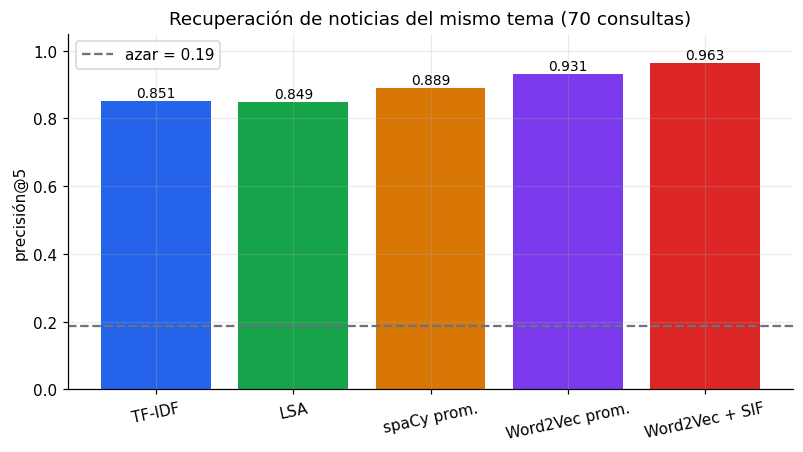

In [11]:
X_temas_tfidf = vectorizador.transform(docs_temas)
X_temas_lsa = Normalizer().fit_transform(lsa.transform(X_temas_tfidf))
X_temas_spacy = np.vstack([promedio_vectores(t, vector_spacy, DIM_SPACY) for t in tokens_temas])
X_temas_w2v = np.vstack([promedio_vectores(t, vector_w2v, DIM_W2V) for t in tokens_temas])
X_temas_sif = quitar_componente_principal(
    np.vstack([promedio_ponderado(t, vector_w2v, pesos, DIM_W2V) for t in tokens_temas]), 1)

REPRESENTACIONES = {
    "TF-IDF": X_temas_tfidf, "LSA": X_temas_lsa, "spaCy prom.": X_temas_spacy,
    "Word2Vec prom.": X_temas_w2v, "Word2Vec + SIF": X_temas_sif,
}
AZAR_P5 = 13 / 69
filas = []
for nombre, X in REPRESENTACIONES.items():
    p5, por_doc = precision_en_k(X, y_tema, k=5)
    por_tema = pd.Series(por_doc, index=y_tema).groupby(level=0).mean()
    filas.append({"método": nombre, "p@5": p5, **{f"p@5 {c}": por_tema[c] for c in CLASES}})
recuperacion = pd.DataFrame(filas).set_index("método")
METRICAS["recuperacion_p5"] = recuperacion.round(4).to_dict("index")
METRICAS["recuperacion_p5"]["azar"] = round(AZAR_P5, 4)
display(recuperacion.round(3))

fig, eje = plt.subplots(figsize=(8.5, 4.2))
eje.bar(recuperacion.index, recuperacion["p@5"], color=[AZUL, VERDE, NARANJA, MORADO, ROJO])
for i, v in enumerate(recuperacion["p@5"]):
    eje.text(i, v + 0.012, f"{v:.3f}", ha="center", fontsize=9)
eje.axhline(AZAR_P5, color=GRIS, ls="--", label=f"azar = {AZAR_P5:.2f}")
eje.set(title="Recuperación de noticias del mismo tema (70 consultas)", ylabel="precisión@5", ylim=(0, 1.05))
eje.set_xticklabels(recuperacion.index, rotation=12)
eje.legend()
guardar_figura("fig04_04_precision_at5")

In [12]:
# Consultas en lenguaje natural sobre el corpus completo: TF-IDF literal frente a LSA.
CONSULTAS = [
    "el equipo ganó el partido de la liga de fútbol",
    "la moneda europea se depreció frente al dólar en la bolsa",
    "el juez dictó prisión para los acusados del delito",
]
X_corpus_lsa = Normalizer().fit_transform(lsa.transform(X_corpus))

def buscar(consulta, k=3):
    lemas_consulta = " ".join(lemas_de_contenido(nlp(consulta)))
    q = vectorizador.transform([lemas_consulta])
    sim_tfidf = cosine_similarity(q, X_corpus)[0]
    q_lsa = Normalizer().fit_transform(lsa.transform(q))
    sim_lsa = cosine_similarity(q_lsa, X_corpus_lsa)[0]
    salida = []
    for metodo, sim in (("TF-IDF", sim_tfidf), ("LSA", sim_lsa)):
        for puesto, i in enumerate(np.argsort(-sim)[:k], 1):
            salida.append({"consulta": consulta[:38] + "…", "método": metodo, "puesto": puesto,
                           "coseno": round(float(sim[i]), 3), "id": int(i),
                           "noticia": quitar_cabecera_agencia(corpus.texto[i])[:95] + "…"})
    return salida

resultados_consultas = pd.DataFrame([f for c in CONSULTAS for f in buscar(c)])
METRICAS["consultas"] = resultados_consultas.drop(columns="noticia").to_dict("records")
for consulta in resultados_consultas.consulta.unique():
    print("»", consulta)
    display(resultados_consultas.query("consulta == @consulta").set_index(["método", "puesto"])[["coseno", "id", "noticia"]])

» el equipo ganó el partido de la liga d…


coseno   id  \
método puesto                
TF-IDF 1        0.262  353   
       2        0.226  769   
       3        0.226  761   
LSA    1        0.638  102   
       2        0.636  354   
       3        0.623  410   

                                                                                                 noticia  
método puesto                                                                                             
TF-IDF 1       El consejo regulador de la denominación de origen "Jamón de Teruel" ha decidido premia...  
       2       El FC Barcelona se ha proclamado por séptima vez en su historia ganador de la Liga Aso...  
       3       El FC Barcelona se ha proclamado por séptima vez en su historia ganador de la Liga Aso...  
LSA    1       La plantilla del Deportivo, campeón de la Liga 1999-2000, se irá mañana de vacaciones ...  
       2       El entrenador del Atlético de Madrid, Fernando Zambrano, opinó hoy que su equipo "se j...  
       3       El Barakaldo-UPV jugará el día. de junio, sábado, el partido clave ante el Garbel Zara...

» la moneda europea se depreció frente a…


coseno   id  \
método puesto                
TF-IDF 1        0.218  208   
       2        0.200  407   
       3        0.181  125   
LSA    1        0.793  208   
       2        0.743  125   
       3        0.721  407   

                                                                                                 noticia  
método puesto                                                                                             
TF-IDF 1       El euro subió hoy frente al dólar en Fráncfort y hacia las 15.00 horas GMT se cambiaba...  
       2       El euro subió hoy frente al dólar en Fráncfort, aunque por la tarde perdió las gananci...  
       3       El rublo subió hoy 0,04 por ciento ante el dólar estadounidense y bajó 0,83 por ciento...  
LSA    1       El euro subió hoy frente al dólar en Fráncfort y hacia las 15.00 horas GMT se cambiaba...  
       2       El rublo subió hoy 0,04 por ciento ante el dólar estadounidense y bajó 0,83 por ciento...  
       3       El euro subió hoy frente al dólar en Fráncfort, aunque por la tarde perdió las gananci...

» el juez dictó prisión para los acusado…


coseno   id  \
método puesto                
TF-IDF 1        0.180  404   
       2        0.179  457   
       3        0.150  485   
LSA    1        0.609  404   
       2        0.609  457   
       3        0.602  129   

                                                                                                 noticia  
método puesto                                                                                             
TF-IDF 1       El fiscal solicita un total de ocho años de prisión para un joven de 21 años acusado d...  
       2       El fiscal solicita un total de ocho años de prisión para un joven de 21 años acusado d...  
       3       El joven de 29 años F. R. C., acusado de dos delitos de intento de asesinato por ataca...  
LSA    1       El fiscal solicita un total de ocho años de prisión para un joven de 21 años acusado d...  
       2       El fiscal solicita un total de ocho años de prisión para un joven de 21 años acusado d...  
       3       Un juzgado de Sevilla ha absuelto al masajista de una clínica, para quien el fiscal pi...

**Análisis.** Los cinco métodos superan ampliamente el azar (0,19): TF-IDF 0,851, LSA 0,849, spaCy 0,889, Word2Vec
promedio 0,931 y Word2Vec + SIF **0,963**, con precisión perfecta en *sucesos y justicia* (1,000) y 0,986 en
*cultura*. El contraste con la sección 2 es el hallazgo central de este notebook: **el mismo TF-IDF que no
correlaciona nada con el juicio humano de similitud (ρ = 0,21) recupera correctamente el 85 % de los vecinos
temáticos**. No hay contradicción: para identificar el tema basta con compartir términos raros (*euro*, *fiscal*,
*liga*), y los fenómenos que rompen el TF-IDF —negación, roles invertidos, polisemia— simplemente no aparecen cuando
la pregunta es «¿de qué habla esto?». Lo que en la sección 2.3 era un defecto de los embeddings (medir cercanía
temática en lugar de equivalencia) aquí es exactamente lo que se pide, y por eso el orden de los métodos se mantiene
pero las diferencias se estrechan.

Las consultas en lenguaje natural muestran la diferencia cualitativa entre el TF-IDF literal y el LSA:

- *«el equipo ganó el partido de la liga de fútbol»*: el primer resultado del TF-IDF es una noticia sobre la
  denominación de origen **«Jamón de Teruel»** (coseno 0,262), un falso positivo puramente léxico; el segundo y el
  tercero son **la misma noticia duplicada** en dos particiones del corpus. El LSA devuelve tres noticias
  deportivas distintas y pertinentes (el Deportivo campeón de Liga, el entrenador del Atlético de Madrid y un partido
  del Barakaldo), ninguna de las cuales tiene por qué compartir todos los términos de la consulta.
- *«la moneda europea se depreció frente al dólar en la bolsa»*: ambos métodos encuentran las tres noticias correctas
  (euro/dólar y rublo/dólar), con la particularidad de que el TF-IDF las recupera **a pesar de que la consulta dice
  "moneda europea" y la noticia dice "euro"**: el acierto viene de *dólar*, no de la sinonimia.
- *«el juez dictó prisión para los acusados del delito»*: el TF-IDF acierta con noticias que repiten *prisión*,
  *acusado* y *fiscal*; el LSA añade en tercer lugar una **absolución** (id 129) que no comparte el vocabulario de la
  consulta pero pertenece al mismo dominio judicial.

La magnitud de los cosenos merece una nota: el TF-IDF devuelve valores de 0,15 a 0,26 y el LSA de 0,60 a 0,79. No
significa que el LSA esté «más seguro». En un espacio disperso de 17.234 dimensiones una consulta de siete lemas
comparte con cualquier noticia una fracción mínima de componentes; tras el SVD, la consulta se describe con 150
factores latentes densos y casi cualquier par de documentos tiene proyecciones no nulas en todos ellos. Los cosenos
de ambos métodos no son comparables entre sí, solo dentro de cada método, y esa es la razón por la que la sección 2.3
reescala antes de comparar perfiles.

## 4. Clasificación de temas (*text classification*)

Tarea: asignar a cada noticia uno de los cinco temas (cultura, deportes, economía, política, sucesos y justicia) a
partir de su texto. Con 70 ejemplos, cualquier partición fija en entrenamiento y prueba deja 14 documentos de prueba
y una varianza inaceptable, así que se evalúa con **validación cruzada estratificada de 5 particiones** y, como
contraste, con **dejar uno fuera** (70 ajustes). Las métricas son la exactitud y el **F1 macro**, que promedia el F1
de las cinco clases dándoles el mismo peso.

### 4.1 Modelos clásicos y red neuronal

Se comparan cinco modelos. Los tres primeros trabajan sobre la matriz TF-IDF dispersa; el cuarto y el quinto, sobre
representaciones densas; el sexto reproduce el laboratorio de clase de Moroney (`Tokenizer`, `pad_sequences`,
`Embedding` + `GlobalAveragePooling1D` + `Dense`), que aprende sus propios vectores de palabra desde cero.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def reglog():
    return LogisticRegression(max_iter=3000, C=10, random_state=SEED)

modelos_texto = {
    "TF-IDF + RegLog": make_pipeline(TfidfVectorizer(min_df=2, sublinear_tf=True), reglog()),
    "TF-IDF + Naive Bayes": make_pipeline(TfidfVectorizer(min_df=2, sublinear_tf=True), MultinomialNB(alpha=0.1)),
    "TF-IDF + SVM lineal": make_pipeline(TfidfVectorizer(min_df=2, sublinear_tf=True), LinearSVC(C=1, random_state=SEED)),
    "LSA(150) + RegLog": make_pipeline(TfidfVectorizer(min_df=2, sublinear_tf=True),
                                       TruncatedSVD(150, random_state=SEED), Normalizer(), reglog()),
}
modelos_densos = {
    "Word2Vec prom. + RegLog": (make_pipeline(Normalizer(), reglog()), X_temas_w2v),
    "spaCy prom. + RegLog": (make_pipeline(Normalizer(), reglog()), X_temas_spacy),
}

filas, predicciones = [], {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for nombre, modelo in modelos_texto.items():
        p_cv = cross_val_predict(modelo, docs_temas, y_tema, cv=cv)
        p_loo = cross_val_predict(modelo, docs_temas, y_tema, cv=LeaveOneOut())
        predicciones[nombre] = p_cv
        filas.append({"modelo": nombre, "exactitud (5-fold)": accuracy_score(y_tema, p_cv),
                      "F1 macro (5-fold)": f1_score(y_tema, p_cv, average="macro"),
                      "exactitud (dejar uno fuera)": accuracy_score(y_tema, p_loo)})
    for nombre, (modelo, X) in modelos_densos.items():
        p_cv = cross_val_predict(modelo, X, y_tema, cv=cv)
        p_loo = cross_val_predict(modelo, X, y_tema, cv=LeaveOneOut())
        predicciones[nombre] = p_cv
        filas.append({"modelo": nombre, "exactitud (5-fold)": accuracy_score(y_tema, p_cv),
                      "F1 macro (5-fold)": f1_score(y_tema, p_cv, average="macro"),
                      "exactitud (dejar uno fuera)": accuracy_score(y_tema, p_loo)})
resultados_clf = pd.DataFrame(filas).set_index("modelo")
display(resultados_clf.round(3))

,exactitud (5-fold),F1 macro (5-fold),exactitud (dejar uno fuera)
modelo,,,
TF-IDF + RegLog,0.957,0.957,0.957
TF-IDF + Naive Bayes,0.914,0.914,0.957
TF-IDF + SVM lineal,0.957,0.957,0.971
LSA(150) + RegLog,0.957,0.957,0.971
Word2Vec prom. + RegLog,1.000,1.000,0.986
spaCy prom. + RegLog,0.943,0.941,0.957


In [14]:
# Red neuronal al estilo del laboratorio de clase: se entrena una por partición para no contaminar la
# evaluación (el tokenizador se ajusta solo con el texto de entrenamiento).
import keras
from keras import layers
from keras.utils import pad_sequences

NUM_PALABRAS, LARGO, DIM_EMB = 4000, 200, 32
y_indice = np.array([CLASES.index(t) for t in y_tema])

def construir_red(tamano_vocabulario):
    keras.utils.set_random_seed(SEED)
    red = keras.Sequential([
        layers.Input(shape=(LARGO,)),
        layers.Embedding(tamano_vocabulario, DIM_EMB, mask_zero=True),
        layers.GlobalAveragePooling1D(),          # promedia los embeddings de la secuencia
        layers.Dense(24, activation="relu"),
        layers.Dense(len(CLASES), activation="softmax"),
    ])
    red.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.Adam(1e-2), metrics=["accuracy"])
    return red

t0 = time.time()
pred_red = np.empty(len(y_tema), dtype=int)
historias = []
for entrena, prueba in cv.split(docs_temas, y_indice):
    tok = TokenizadorPalabras(num_words=NUM_PALABRAS).fit_on_textos([docs_temas[i] for i in entrena])
    S_tr = pad_sequences(tok.textos_a_secuencias([docs_temas[i] for i in entrena]), maxlen=LARGO, truncating="post")
    S_te = pad_sequences(tok.textos_a_secuencias([docs_temas[i] for i in prueba]), maxlen=LARGO, truncating="post")
    red = construir_red(tok.tamano_vocabulario)
    historias.append(red.fit(S_tr, y_indice[entrena], epochs=30, batch_size=8, verbose=0).history)
    pred_red[prueba] = red.predict(S_te, verbose=0).argmax(axis=1)

pred_red_etiquetas = np.array([CLASES[i] for i in pred_red])
predicciones["Keras Embedding + Pooling"] = pred_red_etiquetas
resultados_clf.loc["Keras Embedding + Pooling"] = {
    "exactitud (5-fold)": accuracy_score(y_tema, pred_red_etiquetas),
    "F1 macro (5-fold)": f1_score(y_tema, pred_red_etiquetas, average="macro"),
    "exactitud (dejar uno fuera)": np.nan,
}
red.summary()
print(f"5 particiones × 30 épocas entrenadas en {time.time() - t0:.1f} s")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 32)        │        99,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 300,545 (1.15 MB)

 Trainable params: 100,181 (391.33 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 200,364 (782.68 KB)

5 particiones × 30 épocas entrenadas en 19.0 s


,exactitud (5-fold),F1 macro (5-fold),exactitud (dejar uno fuera)
modelo,,,
Word2Vec prom. + RegLog,1.000,1.000,0.986
TF-IDF + SVM lineal,0.957,0.957,0.971
TF-IDF + RegLog,0.957,0.957,0.957
LSA(150) + RegLog,0.957,0.957,0.971
Keras Embedding + Pooling,0.957,0.957,NaN
spaCy prom. + RegLog,0.943,0.941,0.957
TF-IDF + Naive Bayes,0.914,0.914,0.957


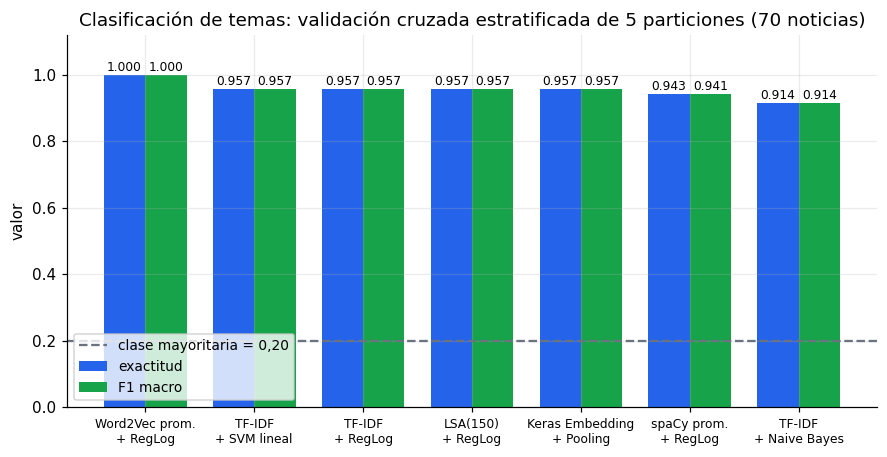

In [15]:
resultados_clf = resultados_clf.sort_values("F1 macro (5-fold)", ascending=False)
METRICAS["clasificacion"] = resultados_clf.round(4).to_dict("index")
display(resultados_clf.round(3))

x = np.arange(len(resultados_clf)); ancho = 0.38
fig, eje = plt.subplots(figsize=(9.5, 4.4))
eje.bar(x - ancho / 2, resultados_clf["exactitud (5-fold)"], ancho, color=AZUL, label="exactitud")
eje.bar(x + ancho / 2, resultados_clf["F1 macro (5-fold)"], ancho, color=VERDE, label="F1 macro")
for i, (a, f) in enumerate(zip(resultados_clf["exactitud (5-fold)"], resultados_clf["F1 macro (5-fold)"])):
    eje.text(i - ancho / 2, a + 0.012, f"{a:.3f}", ha="center", fontsize=8)
    eje.text(i + ancho / 2, f + 0.012, f"{f:.3f}", ha="center", fontsize=8)
eje.axhline(0.2, color=GRIS, ls="--", label="clase mayoritaria = 0,20")
eje.set(title="Clasificación de temas: validación cruzada estratificada de 5 particiones (70 noticias)",
        ylabel="valor", ylim=(0, 1.12))
eje.set_xticks(x); eje.set_xticklabels([m.replace(" + ", "\n+ ") for m in resultados_clf.index], fontsize=8)
eje.legend(fontsize=9, loc="lower left")
guardar_figura("fig04_05_clasificacion_modelos")

**Análisis.** Los siete modelos quedan entre 0,914 y 0,986 de exactitud, frente a un 0,20 de la clase mayoritaria:
el problema, tal como está planteado, está **casi resuelto de antemano**. Cinco temas periodísticos con 14 noticias
cada uno tienen vocabularios tan distintos que cualquier clasificador lineal sobre cualquier representación razonable
acierta. Eso obliga a leer la tabla con cuidado: la diferencia entre el mejor (Word2Vec promedio + regresión
logística, **exactitud y F1 macro de 1,000: ningún error en los 70 documentos**) y el peor (Naive Bayes
multinomial, 0,914, seis errores) son seis documentos. Con n = 70, un único documento vale 1,4 puntos de exactitud,
así que TF-IDF + regresión logística, TF-IDF + SVM lineal, LSA + regresión logística y la red de Keras —todos en
0,957— son **indistinguibles entre sí**. La coincidencia entre la validación cruzada de 5 particiones y la de dejar
uno fuera (que difieren en 0 a 2 documentos por modelo) confirma que no se trata de una partición afortunada. Aun
así, un 1,000 con 70 documentos no debe leerse como «resuelto»: significa que la muestra no contiene ningún caso
difícil para esa representación, y la sección 4.2 muestra que los casos difíciles existen.

Los dos resultados que sí dicen algo son negativos. El primero: la **red neuronal del laboratorio de clase no mejora
a la regresión logística**. La arquitectura `Embedding(32) + GlobalAveragePooling1D + Dense(24) + Dense(5)` tiene
100.181 parámetros entrenables para 56 documentos de entrenamiento por partición —unos 1.800 parámetros por
ejemplo— y aun así se queda en 0,957. La razón es que sus embeddings se aprenden **desde cero con esos 56
documentos**, mientras que los de Word2Vec vienen de las 998 noticias del corpus y los de spaCy de un corpus mucho
mayor. Es la misma capa de *pooling* promedio que la sección 2 mostró incapaz de captar orden: la red no añade
capacidad expresiva sobre el promedio de vectores, solo aprende sus propios vectores con menos datos. El segundo
resultado negativo: **spaCy promedio (0,943) queda por debajo de Word2Vec promedio (1,000)**, al revés que en la
tarea de similitud. Sus vectores son mejores en general, pero los de Word2Vec están entrenados sobre **este** corpus y
por tanto codifican la coocurrencia específica del dominio (nombres de clubes, de partidos políticos, de agencias),
que es justamente la señal que distingue los cinco temas.

### 4.2 Qué confunde el mejor modelo

La matriz de confusión del mejor modelo y las noticias concretas que falla dicen más que la exactitud global: con
cinco temas periodísticos, los errores no se reparten al azar sino que siguen el solapamiento real de los temas.

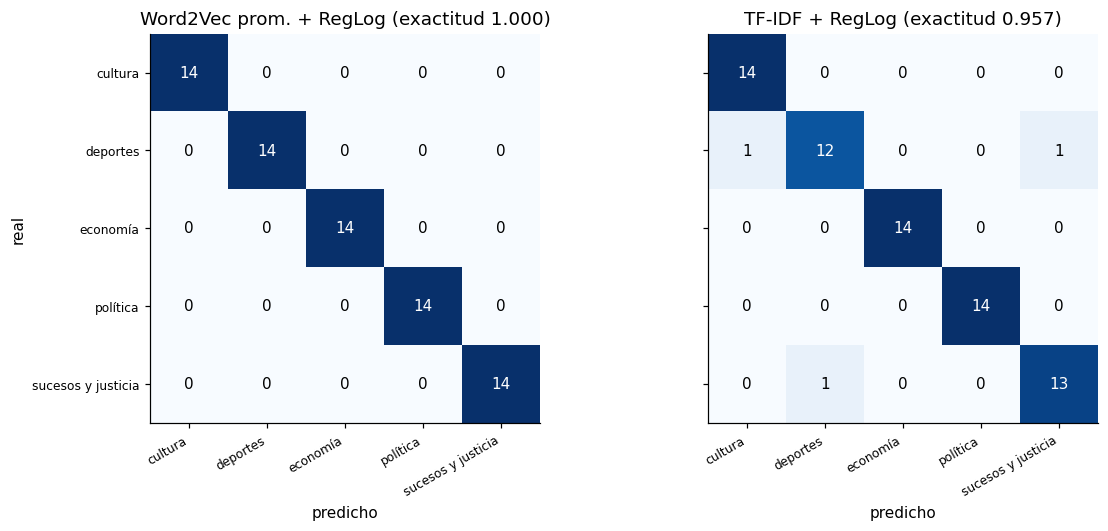

Noticias mal clasificadas por TF-IDF + RegLog: 3 de 70


,id,tema real,predicho,noticia
0,51,deportes,cultura,"El tenista brasileño Gustavo Kuerten, actual número dos del mundo, terminó su romance ..."
1,190,deportes,sucesos y justicia,"El ciclista italiano Antonio Virriale, del Panaria-Gaerne y que hoy, martes, se ha caí..."
2,391,sucesos y justicia,deportes,Las intensas lluvias que castigan a Colombia desde hace seis días han ocasionado al me...


In [16]:
mejor = resultados_clf.index[0]
pred_mejor = predicciones[mejor]
matriz = confusion_matrix(y_tema, pred_mejor, labels=CLASES)
METRICAS["matriz_confusion"] = {"modelo": mejor, "clases": CLASES, "matriz": matriz.tolist()}

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.6))
for eje, (pred, titulo) in zip(ejes, [(pred_mejor, mejor), (predicciones["TF-IDF + RegLog"], "TF-IDF + RegLog")]):
    m = confusion_matrix(y_tema, pred, labels=CLASES)
    eje.imshow(m, cmap="Blues", vmin=0, vmax=14)
    for i in range(len(CLASES)):
        for j in range(len(CLASES)):
            eje.text(j, i, m[i, j], ha="center", va="center", fontsize=10,
                     color="white" if m[i, j] > 8 else "black")
    eje.set(title=f"{titulo} (exactitud {accuracy_score(y_tema, pred):.3f})",
            xlabel="predicho", ylabel="real" if eje is ejes[0] else "")
    eje.set_xticks(range(len(CLASES))); eje.set_xticklabels(CLASES, rotation=30, ha="right", fontsize=8)
    eje.set_yticks(range(len(CLASES))); eje.set_yticklabels(CLASES if eje is ejes[0] else [], fontsize=8)
    eje.grid(False)
guardar_figura("fig04_06_matriz_confusion")

# Noticias mal clasificadas por el modelo léxico (el que más se confunde de los dos mostrados).
fallos = [(i, y_tema[i], predicciones["TF-IDF + RegLog"][i]) for i in range(len(y_tema))
          if predicciones["TF-IDF + RegLog"][i] != y_tema[i]]
tabla_fallos = pd.DataFrame([{"id": temas.id_doc[i], "tema real": real, "predicho": pred,
                              "noticia": quitar_cabecera_agencia(corpus.texto[temas.id_doc[i]])[:150] + "…"}
                             for i, real, pred in fallos])
METRICAS["errores_tfidf_reglog"] = tabla_fallos.drop(columns="noticia").to_dict("records")
print(f"Noticias mal clasificadas por TF-IDF + RegLog: {len(fallos)} de {len(y_tema)}")
display(tabla_fallos)

**Análisis.** La matriz del mejor modelo es **exactamente diagonal**: 14 aciertos en cada una de las cinco clases,
ningún error. La del modelo léxico tiene tres errores y son informativos, porque los tres son documentos cuyo
vocabulario distintivo pertenece al registro de otra clase:

- **id 51, deportes → cultura.** *«El tenista brasileño Gustavo Kuerten […] terminó su romance de varios meses con la
  modelo Vanessa Schultz, que ha decidido posar desnuda […] en la edición nacional de [una revista]»*. La noticia es
  de la sección de deportes por su protagonista, pero su léxico (*romance*, *modelo*, *posar*, *revista*,
  *fotografía*, *escenario*) es el de la prensa de espectáculos, que en esta muestra alimenta la clase *cultura*.
- **id 190, deportes → sucesos y justicia.** *«El ciclista italiano Antonio Virriale […] se ha caído mientras
  disputaba la décima etapa del Giro»*. Una caída con lesión comparte vocabulario (*caer*, *sufrir*, *localidad*,
  *transportar*, *hospital*) con los accidentes de tráfico que dominan *sucesos y justicia*.
- **id 391, sucesos y justicia → deportes.** *«Las intensas lluvias que castigan a Colombia […] han ocasionado al
  menos [varios] muertos, desaparecidos y damnificados […] en los departamentos de Nariño y Putumayo»*. Es un desastre
  natural en Colombia, mientras que la clase *sucesos y justicia* de esta muestra está construida casi por completo con
  juicios y accidentes en España; sus lemas geográficos y meteorológicos no aparecen en ningún otro documento de su
  clase.

Los tres errores comparten un patrón: **no son errores de vocabulario, son errores de definición de clase**. Las
categorías de una sección periodística se definen por el criterio editorial (quién protagoniza, dónde se publica) y no
por el léxico, de modo que hay documentos cuya etiqueta correcta es lingüísticamente indistinguible de otra clase. Un
modelo mejor no los resolvería del todo; solo lo haría una etiquetación más fina (subdividir *sucesos* en judicial y
catástrofes, por ejemplo) o más ejemplos de cada subtipo. Que el promedio de Word2Vec acierte los tres no significa
que entienda el criterio editorial: significa que en su espacio esas tres noticias siguen cerca de sus compañeras de
clase por otras razones (los nombres propios, el país, el vocabulario deportivo de fondo).

Conviene matizar la expectativa habitual de que *política* se confunda con *sucesos y justicia*: en esta muestra
**no ocurre ni una vez**. Los lemas de *política* (*gobierno*, *socialista*, *pp*, *psoe*, *congreso*, *candidato*)
son extremadamente específicos y no aparecen en las otras clases. Las confusiones reales son deportes ↔ cultura y
deportes ↔ sucesos, y en ambos casos el eje es el **deportista como persona** (su vida privada, su accidente) frente
al deportista como competidor.

### 4.3 Curva de aprendizaje: cuánto texto anotado hace falta

Con 14 ejemplos por clase casi todos los modelos rozan el techo, de modo que la comparación anterior no discrimina.
La pregunta útil en la práctica es otra: **con cuántas noticias anotadas por tema empieza a funcionar cada
representación**. Se entrena con 1, 2, 4, 8 y 10 ejemplos por clase elegidos al azar, se evalúa en el resto y se
repite 30 veces por tamaño para promediar la varianza del muestreo.

750 ajustes en 110.5 s


,TF-IDF + RegLog,TF-IDF + Naive Bayes,LSA(150) + RegLog,Word2Vec prom. + RegLog,spaCy prom. + RegLog
ejemplos por clase,,,,,
1,0.686,0.700,0.634,0.912,0.804
2,0.810,0.811,0.771,0.943,0.901
4,0.917,0.903,0.875,0.970,0.931
8,0.967,0.959,0.943,0.971,0.947
10,0.975,0.973,0.957,0.993,0.963


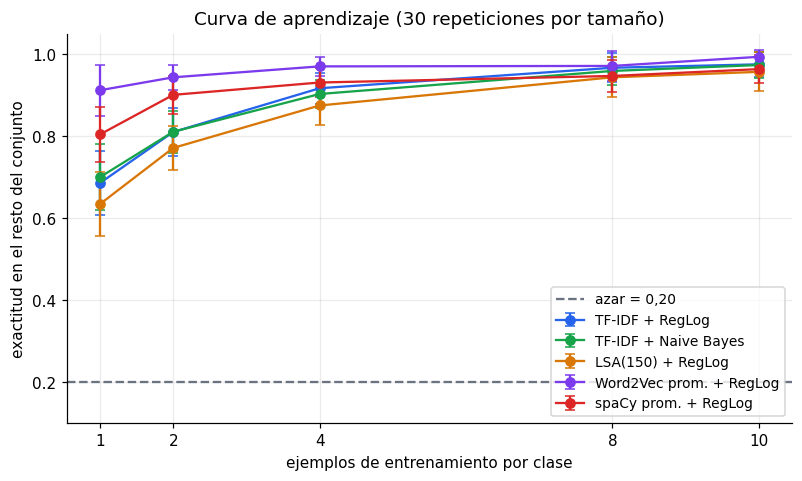

In [17]:
TAMANOS, REPETICIONES = [1, 2, 4, 8, 10], 30
docs_array = np.array(docs_temas, dtype=object)
rng = np.random.default_rng(SEED)

familias = {
    "TF-IDF + RegLog": ("texto", None), "TF-IDF + Naive Bayes": ("texto", None),
    "LSA(150) + RegLog": ("densa", X_temas_lsa), "Word2Vec prom. + RegLog": ("densa", X_temas_w2v),
    "spaCy prom. + RegLog": ("densa", X_temas_spacy),
}
curva = {nombre: {t: [] for t in TAMANOS} for nombre in familias}
t0 = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for tamano in TAMANOS:
        for _ in range(REPETICIONES):
            entrena = np.concatenate([rng.choice(np.where(y_tema == c)[0], tamano, replace=False) for c in CLASES])
            prueba = np.setdiff1d(np.arange(len(y_tema)), entrena)
            for nombre, (tipo, X) in familias.items():
                if tipo == "texto":
                    # El IDF se reestima con los pocos documentos disponibles: es la situación real.
                    vec = TfidfVectorizer(sublinear_tf=True).fit(docs_array[entrena])
                    clf = MultinomialNB(alpha=0.1) if "Naive" in nombre else reglog()
                    clf.fit(vec.transform(docs_array[entrena]), y_tema[entrena])
                    puntaje = clf.score(vec.transform(docs_array[prueba]), y_tema[prueba])
                else:
                    clf = make_pipeline(Normalizer(), reglog()).fit(X[entrena], y_tema[entrena])
                    puntaje = clf.score(X[prueba], y_tema[prueba])
                curva[nombre][tamano].append(puntaje)
print(f"{len(TAMANOS) * REPETICIONES * len(familias)} ajustes en {time.time() - t0:.1f} s")

medias = pd.DataFrame({n: [np.mean(curva[n][t]) for t in TAMANOS] for n in familias}, index=TAMANOS)
desv = pd.DataFrame({n: [np.std(curva[n][t]) for t in TAMANOS] for n in familias}, index=TAMANOS)
medias.index.name = "ejemplos por clase"
METRICAS["curva_aprendizaje"] = {"tamanos": TAMANOS, "media": medias.round(4).to_dict(),
                                 "desviacion": desv.round(4).to_dict()}
display(medias.round(3))

fig, eje = plt.subplots(figsize=(8.5, 4.6))
for nombre, color in zip(familias, [AZUL, VERDE, NARANJA, MORADO, ROJO]):
    eje.errorbar(TAMANOS, medias[nombre], yerr=desv[nombre], marker="o", capsize=3, color=color, label=nombre)
eje.axhline(0.2, color=GRIS, ls="--", label="azar = 0,20")
eje.set(title=f"Curva de aprendizaje ({REPETICIONES} repeticiones por tamaño)",
        xlabel="ejemplos de entrenamiento por clase", ylabel="exactitud en el resto del conjunto",
        xticks=TAMANOS, ylim=(0.1, 1.05))
eje.legend(fontsize=9, loc="lower right")
guardar_figura("fig04_07_curva_aprendizaje")

**Análisis.** La curva de aprendizaje separa lo que la sección 4.1 no podía separar:

| Ejemplos por clase | TF-IDF + RegLog | TF-IDF + NB | LSA + RegLog | Word2Vec + RegLog | spaCy + RegLog |
|---|---|---|---|---|---|
| 1 | 0,686 | 0,700 | 0,634 | **0,912** | 0,804 |
| 2 | 0,810 | 0,811 | 0,771 | **0,943** | 0,901 |
| 4 | 0,917 | 0,903 | 0,875 | **0,970** | 0,931 |
| 8 | 0,967 | 0,959 | 0,943 | **0,971** | 0,947 |
| 10 | 0,975 | 0,973 | 0,957 | **0,993** | 0,963 |

Con **un solo ejemplo anotado por clase** (cinco documentos en total) el promedio de vectores Word2Vec alcanza 0,912
de exactitud sobre los 65 documentos restantes, mientras que el TF-IDF se queda en 0,686: **22,6 puntos de
diferencia**. A diez ejemplos por clase la diferencia se reduce a 1,8 puntos (0,993 frente a 0,975) y deja de ser
apreciable. La explicación es directa: los embeddings ya han colocado los documentos del mismo tema en la misma
región del espacio **antes de ver una sola etiqueta**, porque ese trabajo lo hizo Word2Vec con las 998 noticias sin
anotar; al clasificador solo le queda trazar cinco fronteras. El TF-IDF, en cambio, no sabe nada del significado: con
cinco documentos su IDF se estima sobre cinco documentos y la mayoría de los términos del conjunto de prueba son
palabras que nunca vio.

Dos detalles secundarios. El **LSA queda por debajo del TF-IDF en todos los tamaños** (de 0,634 a 0,957 frente a
0,686 a 0,975): las 150 componentes ajustadas sobre el corpus completo conservan la estructura temática general pero
descartan precisamente los términos raros y discriminativos que hacen fácil esta tarea, y además su desviación típica
es la mayor del grupo (0,048 con 10 ejemplos por clase, frente a 0,017 de Word2Vec), es decir, es el método más
sensible a qué documentos toquen en el muestreo. Y **spaCy vuelve a quedar entre los dos grupos** (0,804 con un
ejemplo por clase): buenos vectores generales, pero sin el conocimiento del dominio que Word2Vec extrae del propio
corpus.

La conclusión práctica es que la exactitud final no es el criterio de decisión cuando anotar cuesta dinero: los cinco
modelos acaban en el mismo sitio, pero para llegar a 0,90 el promedio de embeddings necesita **un** ejemplo por clase
y el TF-IDF necesita **cuatro**, es decir, cuatro veces más anotación humana para el mismo resultado.

### 4.4 Términos más informativos por tema

La regresión logística sobre TF-IDF es interpretable: el coeficiente de cada lema en cada clase indica cuánto empuja
ese lema hacia ese tema. Es la ventaja práctica que se pierde al pasar a embeddings densos.

,cultura,deportes,economía,política,sucesos y justicia
0,obra,liga,millón,gobierno,civil
1,libro,disputar,ciento,socialista,guardia
2,artista,equipo,dólares,pp,acusado
3,novela,partido,banco,deber,herido
4,música,torneo,euro,candidato,joven
5,escritor,entrenador,dólar,presidente,dos
6,literatura,técnico,estadounidense,congreso,delito
7,cultura,final,bolsa,psoe,accidente
8,exposición,sánchez,unidad,reforma,vehículo
9,pérez,gol,bajar,secretario,informar


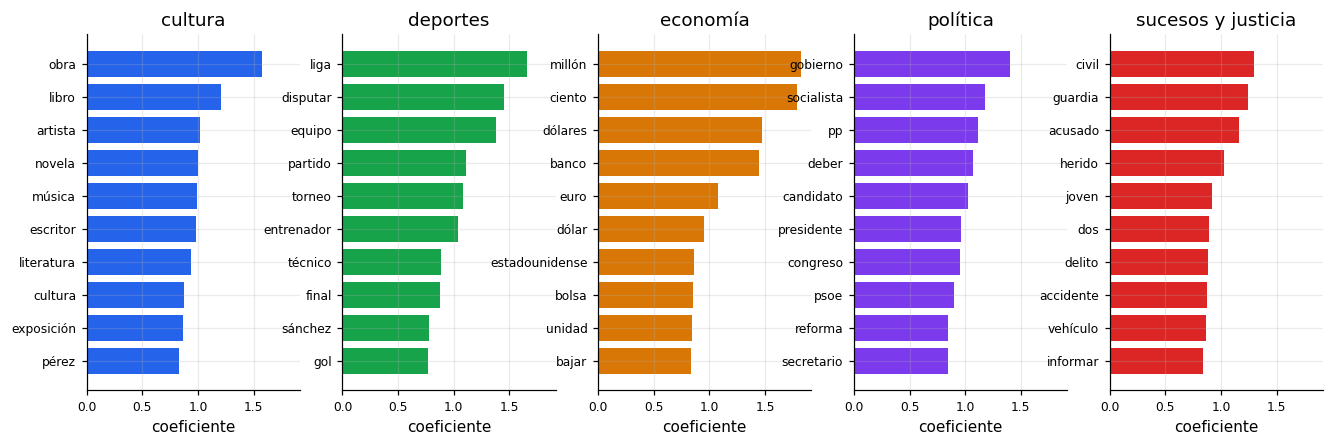

In [18]:
vec_completo = TfidfVectorizer(min_df=2, sublinear_tf=True).fit(docs_temas)
clf_completo = reglog().fit(vec_completo.transform(docs_temas), y_tema)
lemas_vocab = np.array(vec_completo.get_feature_names_out())
K = 10
informativos = {}
for i, clase in enumerate(clf_completo.classes_):
    top = np.argsort(-clf_completo.coef_[i])[:K]
    informativos[clase] = [(lemas_vocab[j], round(float(clf_completo.coef_[i][j]), 3)) for j in top]
METRICAS["terminos_informativos"] = informativos
display(pd.DataFrame({c: [p for p, _ in v] for c, v in informativos.items()}))

fig, ejes = plt.subplots(1, len(CLASES), figsize=(14.5, 4.2), sharex=True)
for eje, clase, color in zip(ejes, clf_completo.classes_, [AZUL, VERDE, NARANJA, MORADO, ROJO]):
    palabras = [p for p, _ in informativos[clase]][::-1]
    valores = [v for _, v in informativos[clase]][::-1]
    eje.barh(palabras, valores, color=color)
    eje.set(title=clase, xlabel="coeficiente")
    eje.tick_params(labelsize=8)
guardar_figura("fig04_08_terminos_informativos")

**Análisis.** Los coeficientes son legibles y en su mayoría coinciden con lo que un lector esperaría de cada sección:
*cultura* se reconoce por **obra, libro, artista, novela, música, escritor, literatura, exposición**; *deportes* por
**liga, disputar, equipo, partido, torneo, entrenador, técnico, final, gol**; *economía* por **millón, ciento,
dólares, banco, euro, dólar, estadounidense, bolsa, bajar**; *política* por **gobierno, socialista, pp, candidato,
presidente, congreso, psoe, reforma, secretario**; y *sucesos y justicia* por **civil, guardia, acusado, herido,
joven, delito, accidente, vehículo**. El caso más ilustrativo es *civil* y *guardia*, los dos coeficientes más altos
de su clase: no son palabras sobre el crimen sino el nombre del cuerpo policial que aparece como fuente en casi todas
las notas de sucesos españolas. El modelo aprende **quién informa**, no de qué se informa.

Dos señales de sobreajuste confirman el tamaño del conjunto. *pérez* aparece entre los diez términos más informativos
de *cultura* y *sánchez* entre los de *deportes*: son apellidos de personas concretas que aparecen en una o dos
noticias, y el modelo los toma como evidencia del tema. Y *deber* en *política* es un verbo modal sin contenido
temático, que entra en la lista por un sesgo de registro (las declaraciones políticas usan «debe», «debería») y no por
significado. Con 14 documentos por clase, parte de la «evidencia» que el modelo usa no es reutilizable en ningún otro
corpus.

Esta lista es la ventaja que se pierde al cambiar de representación: el mejor clasificador de la sección 4.1
(Word2Vec promedio) no admite un análisis equivalente, porque la decisión se toma sobre 200 dimensiones latentes en
las que **no hay ninguna palabra**. El compromiso es explícito: 4,3 puntos de exactitud a cambio de poder auditar
por qué el modelo decidió lo que decidió, lo que en un sistema en producción —donde hay que justificar un error ante
quien lo sufre— puede ser más valioso que la exactitud.

## 5. Exportación de métricas

In [19]:
(DIR_RES / "metricas_04.json").write_text(
    json.dumps(METRICAS, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Guardado:", DIR_RES / "metricas_04.json")
print("Claves:", list(METRICAS))
print("Figuras:", sorted(p.name for p in DIR_FIG.glob("fig04_*.png")))

Guardado: /home/claude/lab-procesamiento-texto/notebooks/resultados/metricas_04.json
Claves: ['corpus', 'evaluacion', 'sts_correlaciones', 'sts_perfil_fenomeno', 'sts_error_por_fenomeno', 'recuperacion_p5', 'consultas', 'clasificacion', 'matriz_confusion', 'errores_tfidf_reglog', 'curva_aprendizaje', 'terminos_informativos']
Figuras: ['fig04_01_correlacion_sts.png', 'fig04_02_perfil_fenomenos.png', 'fig04_03_dispersion_fenomenos_criticos.png', 'fig04_04_precision_at5.png', 'fig04_05_clasificacion_modelos.png', 'fig04_06_matriz_confusion.png', 'fig04_07_curva_aprendizaje.png', 'fig04_08_terminos_informativos.png']


## 6. Hallazgos del notebook

- **El coseno sobre TF-IDF no mide significado**: ρ de Spearman 0,21 (p = 0,31) y Pearson −0,01 frente a la anotación
  humana de 26 pares. Los vectores estáticos promediados llegan a 0,55 (spaCy) y la variante SIF de Word2Vec a 0,47,
  todavía muy lejos de los 0,74–0,85 que obtienen los codificadores contextuales entrenados para la tarea
  (Reimers y Gurevych, 2019).
- **La ganancia de los embeddings está localizada**: toda su ventaja viene de la *brecha léxica*, donde el TF-IDF cae
  a 0,04 (reescalado) frente a 0,97 humano y los embeddings suben a 0,77–0,79. En cambio **pagan un precio** en
  *mismo tema* (0,59–0,64 frente a 0,26 humano): miden cercanía temática, no equivalencia semántica.
- **Tres fenómenos son inaccesibles para las cinco representaciones**, con un error de orden de +0,67, +0,55 y +0,40:
  *roles invertidos* (coseno exactamente 1,0 en los cinco métodos, porque la bolsa de palabras y la media de vectores
  son conmutativas), *negación o antónimo* (el *no* se conserva, pero aporta un lema entre cuatro, y *aumentar* y
  *disminuir* comparten contexto) y *polisemia* (un vector estático por forma mezcla los sentidos de *banco*).
- **La misma representación que falla en similitud funciona en recuperación**: el TF-IDF obtiene precisión@5 = 0,851
  (azar 0,19) y Word2Vec + SIF 0,963. Identificar el tema solo exige compartir términos raros; los fenómenos que
  rompen la bolsa de palabras no intervienen. En las consultas en lenguaje natural el LSA evita los falsos positivos
  léxicos del TF-IDF (que devuelve una noticia sobre «Jamón de Teruel» para una consulta de fútbol).
- **La clasificación de 5 temas con 70 noticias está saturada**: los siete modelos quedan entre 0,914 y 1,000 de
  exactitud (F1 macro 0,914–1,000), y las diferencias equivalen a uno a seis documentos. La red de Keras del
  laboratorio de clase (`Embedding` + `GlobalAveragePooling1D` + `Dense`, 100.181 parámetros entrenables) llega a
  0,957: **no mejora a la regresión logística**, porque aprende sus embeddings desde cero con 56 documentos.
- **La curva de aprendizaje es el criterio que sí discrimina**: con un ejemplo anotado por clase el promedio de
  vectores Word2Vec alcanza 0,912 de exactitud y el TF-IDF 0,686 (22,6 puntos de diferencia); con diez la diferencia
  baja a 1,8 puntos. Para llegar a 0,90 los embeddings necesitan un ejemplo por clase y el TF-IDF cuatro: el
  preentrenamiento no supervisado sustituye anotación humana.
- **Los errores de clasificación son de definición de clase, no de vocabulario**: la ruptura sentimental de un tenista
  se clasifica como *cultura*, la caída de un ciclista como *sucesos*, y unas inundaciones en Colombia como
  *deportes*. Las secciones periodísticas se definen por criterio editorial y hay documentos lingüísticamente
  indistinguibles de otra clase.
- **La interpretabilidad se pierde al pasar a vectores densos**: la regresión logística sobre TF-IDF señala *guardia*
  y *civil* como los términos más informativos de *sucesos y justicia* (el modelo aprende **quién informa**) y delata
  su propio sobreajuste con apellidos como *pérez* y *sánchez*; el mejor clasificador, 4,3 puntos por encima, no
  admite ninguna inspección equivalente.

## Referencias

- Arora, S., Liang, Y. y Ma, T. (2017). A simple but tough-to-beat baseline for sentence embeddings. En
  *Proceedings of the 5th International Conference on Learning Representations (ICLR 2017)*.
- Deerwester, S., Dumais, S. T., Furnas, G. W., Landauer, T. K. y Harshman, R. (1990). Indexing by latent semantic
  analysis. *Journal of the American Society for Information Science, 41*(6), 391–407.
  https://doi.org/10.1002/(SICI)1097-4571(199009)41:6<391::AID-ASI1>3.0.CO;2-9
- Mikolov, T., Sutskever, I., Chen, K., Corrado, G. y Dean, J. (2013). Distributed representations of words and
  phrases and their compositionality. En *Advances in Neural Information Processing Systems 26* (pp. 3111–3119).
- Moroney, L. (2019). *dlaicourse: Notebooks for learning deep learning* [Repositorio]. GitHub.
  https://github.com/lmoroney/dlaicourse
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P.,
  Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. y Duchesnay, É. (2011).
  Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Reimers, N. y Gurevych, I. (2019). Sentence-BERT: Sentence embeddings using Siamese BERT-networks. En
  *Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing* (pp. 3982–3992).
  https://doi.org/10.18653/v1/D19-1410
- Řehůřek, R. y Sojka, P. (2010). Software framework for topic modelling with large corpora. En *Proceedings of the
  LREC 2010 Workshop on New Challenges for NLP Frameworks* (pp. 45–50).
- Tjong Kim Sang, E. F. (2002). Introduction to the CoNLL-2002 shared task: Language-independent named entity
  recognition. En *Proceedings of CoNLL-2002* (pp. 155–158).